In [1]:
import numpy as np

In [6]:
V = np.array([[0.751,0.284,0.502,0.321],
              [0.380,0.547,-0.675,-0.317],
              [0.513,-0.709,-0.059,-0.481],
              [0.168,-0.344,-0.537,0.752]])

In [7]:
V_T = V.T

In [9]:
G = V@V_T
G

array([[ 9.997020e-01,  1.210000e-04, -1.120000e-04,  2.900000e-04],
       [ 1.210000e-04,  9.997230e-01, -5.810000e-04, -2.370000e-04],
       [-1.120000e-04, -5.810000e-04,  1.000692e+00,  5.100000e-05],
       [ 2.900000e-04, -2.370000e-04,  5.100000e-05,  1.000433e+00]])

In [10]:
G_2 = V_T @ V
G_2

array([[ 9.997940e-01, -3.650000e-04,  1.900000e-05,  1.940000e-04],
       [-3.650000e-04,  1.000882e+00, -9.800000e-05,  1.060000e-04],
       [ 1.900000e-05, -9.800000e-05,  9.994790e-01, -3.280000e-04],
       [ 1.940000e-04,  1.060000e-04, -3.280000e-04,  1.000395e+00]])

In [11]:
v_1 = np.array([[0.751],
                [0.380],
                [0.513],
                [0.168]])

In [12]:
v_1_T = v_1.T

In [17]:
v_1_tensor = v_1 @ v_1_T

In [18]:
np.linalg.det(v_tensor)

np.float64(3.3177352663280803e-52)

In [16]:
v_2 = V[:,1,None]
v_2

array([[ 0.284],
       [ 0.547],
       [-0.709],
       [-0.344]])

In [20]:
v_2_tensor = v_2 @ v_2.T
v_2_tensor

array([[ 0.080656,  0.155348, -0.201356, -0.097696],
       [ 0.155348,  0.299209, -0.387823, -0.188168],
       [-0.201356, -0.387823,  0.502681,  0.243896],
       [-0.097696, -0.188168,  0.243896,  0.118336]])

In [21]:
np.linalg.det(v_2_tensor)

np.float64(-1.3432567678327787e-51)

In [23]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

In [24]:
iris = load_iris()

In [25]:
X = iris.data

In [26]:
y = iris.target

In [35]:
feature_names = ['Sepal length, x1','Sepal width, x2','Petal length, x3','Petal width, x4']
X_df = pd.DataFrame(X,columns = feature_names) #X本身只有4列,这里给不同的列重命名

In [36]:
X_df

,"Sepal length, x1","Sepal width, x2","Petal length, x3","Petal width, x4"
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [38]:
X = X_df.to_numpy()

In [39]:
G = X.T @ X

In [40]:
D,V = np.linalg.eig(G)

In [42]:
def heatmap(Matrices,Titles,Ranges,Equal_tags):#Ranges控制热力图颜色范围
    M1,M2,M3 = Matrices
    Title_1,Title_2,Title_3 = Titles

    fig,axs = plt.subplots(1,5,figsize = (12,3))

    plt.sca(axs[0])
    ax = sns.heatmap(M1,cmap = 'RdYlBu_r',vmin = Ranges[0][0],vmax = Ranges[0][1],
                    cbar = False,xticklabels = False,yticklabels = False)

    if Equal_tags[0]:
        ax.set_aspect('equal')#比例相等
    plt.title(Title_1)

    plt.sca(axs[1])
    plt.title('=')
    plt.axis('off')

    plt.sca(axs[2])
    ax = sns.heatmap(M2,cmap = 'RdYlBu_r',vmin = Ranges[1][0],vmax = Ranges[1][1], 
                    cbar = False,xticklabels = False,yticklabels = False)

    if Equal_tags[1]:
        ax.set_aspect('equal')
    plt.title(Title_2)

    plt.sca(axs[3])
    plt.title('@')
    plt.axis('off')

    plt.sca(axs[4])
    ax = sns.heatmap(M3,cmap = 'RdYlBu_r',vmin = Ranges[2][0],vmax = Ranges[2][1],
                    cbar = False,xticklabels = False,yticklabels = False)

    if Equal_tags[2]:
        ax.set_aspect('equal')
    plt.title(Title_3)

In [51]:
def plot_four_figs(X,v_j,idx):
    z_j = X @ v_j
    Titles = ['X','v_' + str(idx) , 'z_' + str(idx)]
    Ranges = [[-2,11],[-1,1],[-2,11]]
    Equal_tags = [False,True,False]
    heatmap([X,v_j,z_j],Titles,Ranges,Equal_tags)

    X_j = z_j @ v_j.T
    Titles = ['z_' + str(idx),'v_' + str(idx) + '_T','X_' + str(idx)]
    heatmap([z_j,v_j.T,X_j],Titles,Ranges,Equal_tags)

    T_j = v_j @ v_j.T
    Titles = ['T_' + str(idx), 'v_' + str(idx),'v_'+ str(idx) +'.T']
    Ranges = [[-1,1],[-1,1],[-1,1]]
    Equal_tags = [True,True,True]
    heatmap([T_j,v_j,v_j.T],Titles,Ranges,Equal_tags)

    X_j = X @ T_j
    Titles = ['X_' + str(idx),'X','T_' + str(idx)]
    Ranges = [[-2,11],[-2,11],[-1,1]]
    Equal_tags = [False,False,True]
    heatmap([X_j,X,T_j],Titles,Ranges,Equal_tags)

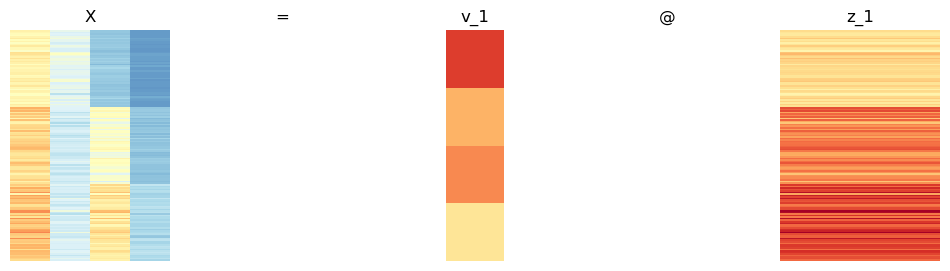

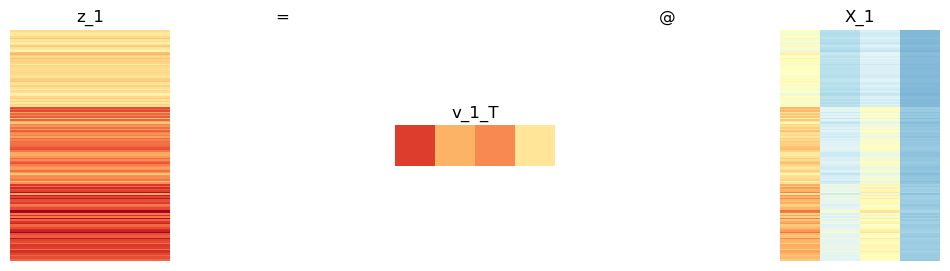

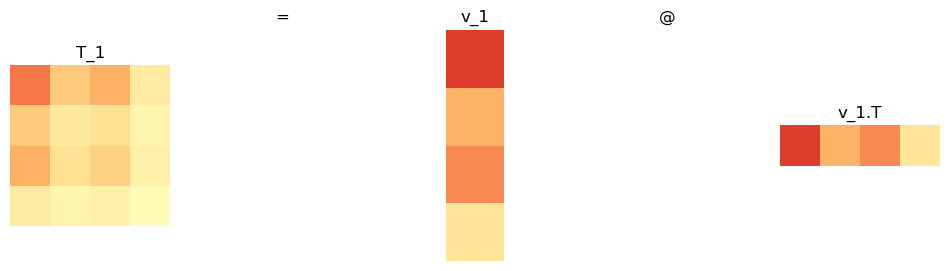

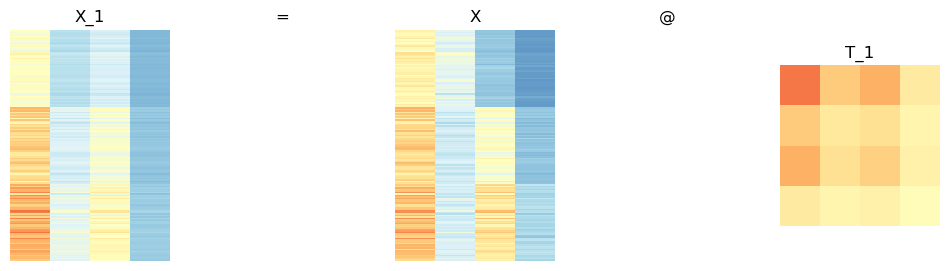

In [53]:
v1 = V[:,0].reshape((-1,1))
plot_four_figs(X,v1,1)

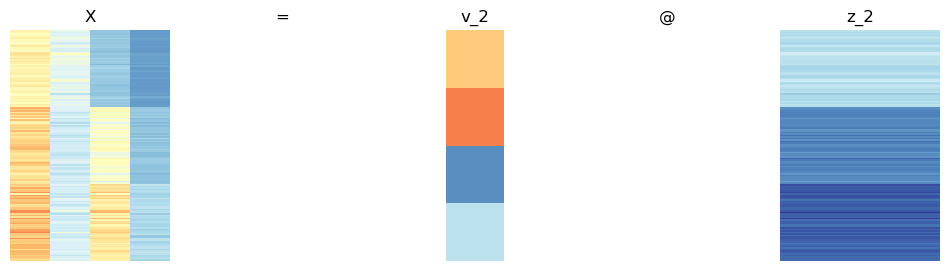

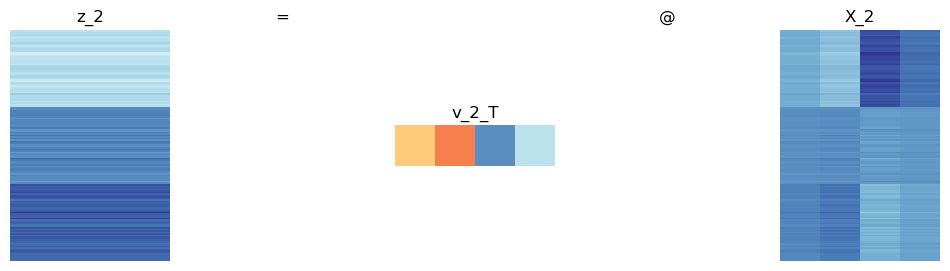

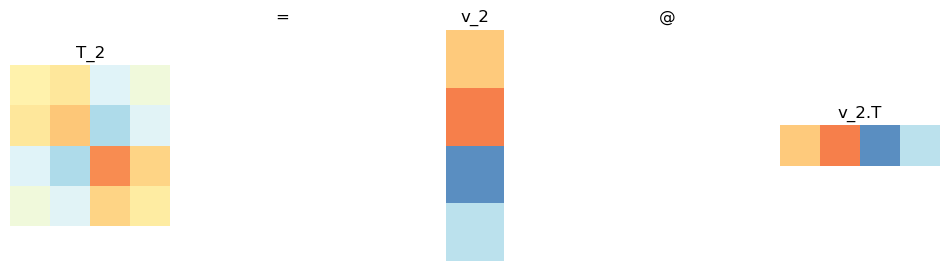

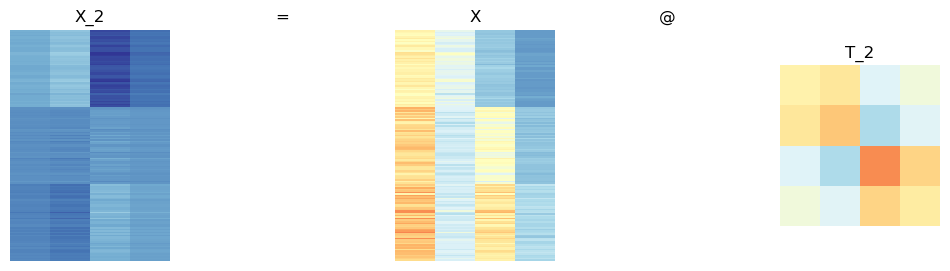

In [54]:
v2 = V[:,1].reshape((-1,1))
plot_four_figs(X,v2,2)

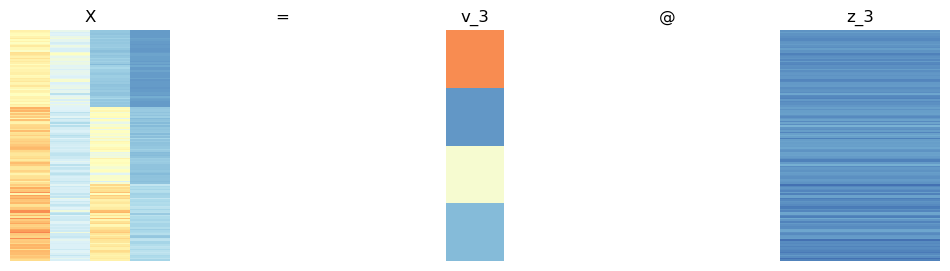

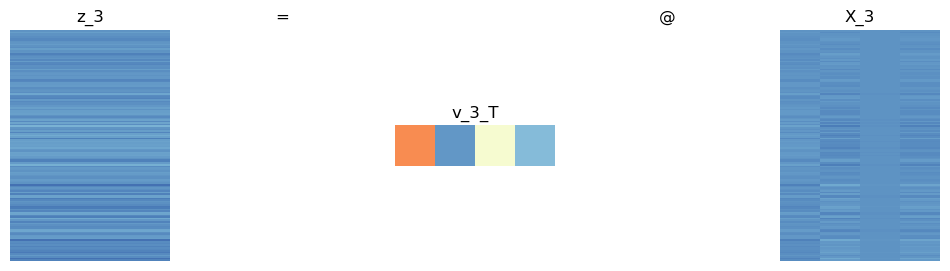

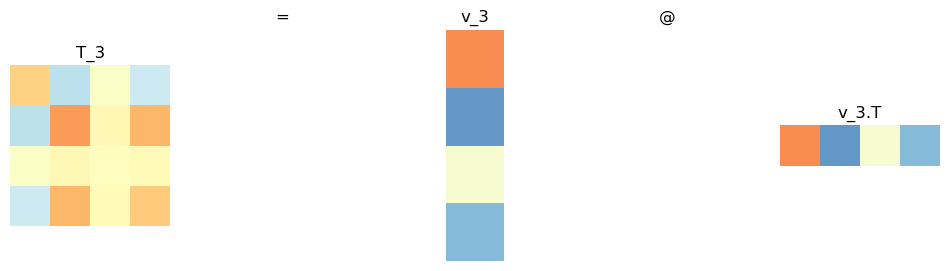

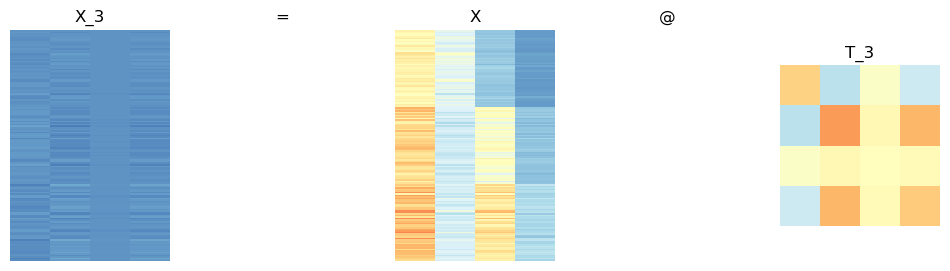

In [55]:
v3 = V[:,2].reshape((-1,1))
plot_four_figs(X,v3,3)

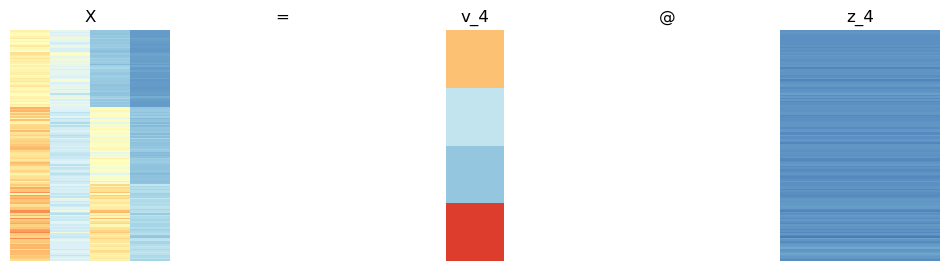

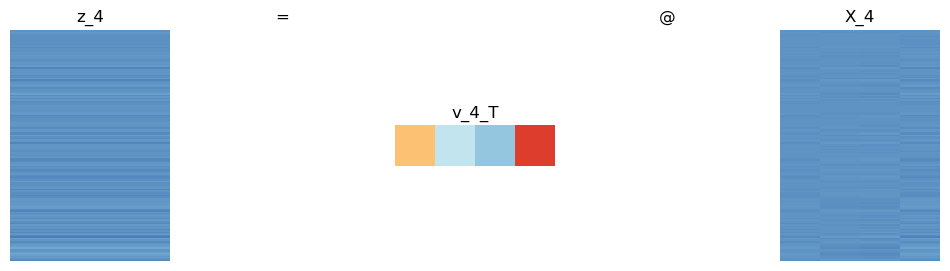

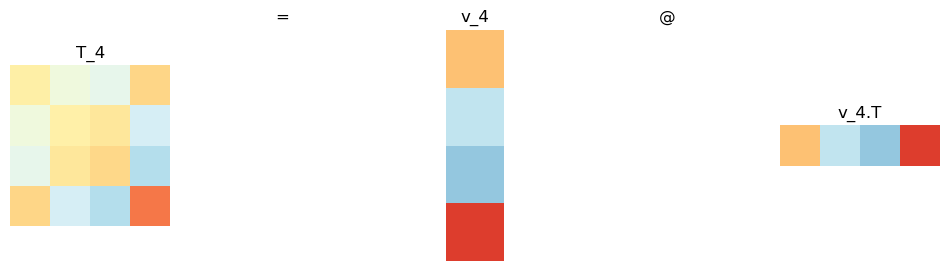

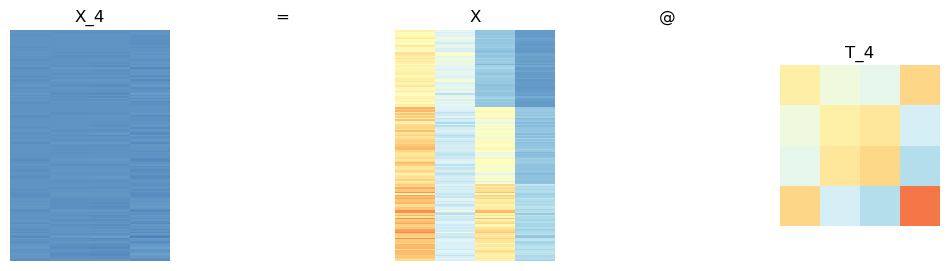

In [56]:
v4 = V[:,3].reshape((-1,1))
plot_four_figs(X,v4,4)